# Dataset Analysis for Numericals Datasets

## Libraries


In [18]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [19]:
%store -r data
data=data

%store -r numerical_cols
numerical_cols=numerical_cols



##  Descriptive Analysis

#### Numerical Data

In [20]:
numerical_cols= data.select_dtypes(include=['int64','float64' ]).columns.tolist()
print(data[numerical_cols].columns)
print(data[numerical_cols])

Index(['year_of_manufacture', 'Engine_power(kilowatt)',
       'Engine_power_(Horsepower)', 'Mileage', 'Nber_previous_owners',
       'damaged_front', 'damaged_rear', 'damaged_left_side',
       'damaged_interior', 'damaged_exterior', 'damaged_tire', 'damaged_rim',
       'damaged_roof_beam', 'damaged_left_door', 'damaged_right_door',
       'damaged_seats', 'interior_dirty', 'damaged_carosserie', 'Sale price'],
      dtype='object')
    year_of_manufacture  Engine_power(kilowatt)  Engine_power_(Horsepower)  \
0                  2022                     120                        163   
1                  2020                      88                        120   
2                  2024                     120                        163   
3                  2020                      88                        120   
4                  2021                      70                         95   
5                  2028                     110                        120   
6               

In [21]:
def kde_plot(x):
    col = x[0]

    plt.figure(figsize=(12,6))

    # Histogramm
    sns.histplot(data[x[0]], kde=False, alpha=0.25)

    # KDE-Plot
    sns.kdeplot(data[x[0]], linewidth=5)
    
    # Calculate mean and median
    mean=data[col].mean()
    median=data[col].median()
    
    # Add mean and median lines
    plt.axvline(mean, color='r', linestyle='--', label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='-', label=f'Median: {median:.2f}')
    
    # Add legend and labels
    plt.legend()
    plt.title(f'KDE Plot of {col}')
    plt.xlabel(x)
    plt.ylabel('Density')

    return plt.show()



In [22]:
# Generate KDE plots for all numerical columns
# for col in numerical_cols:
#     kde_plot([col])

#     print('\n\n')

#### Scatter Plot

In [23]:
def scatter_plot(x):
    col=x[0]

    plt.figure(figsize=(12,6))

    # Scatter plot with regression line 
    sns.scatterplot(x=data[col], y=data['Sale price'], alpha=0.5, color='red')
    sns.regplot(x=data[col], y=data['Sale price'], scatter=False, color='black', line_kws={"linewidth":3})
    # Add labels and title 
    plt.title(f'Scatter Plot of {col} vs Sale Price')
    plt.xlabel(col)
    plt.ylabel('Price (EUR)')

    return plt.show()

In [24]:
# for col in numerical_cols:
#     scatter_plot([col])

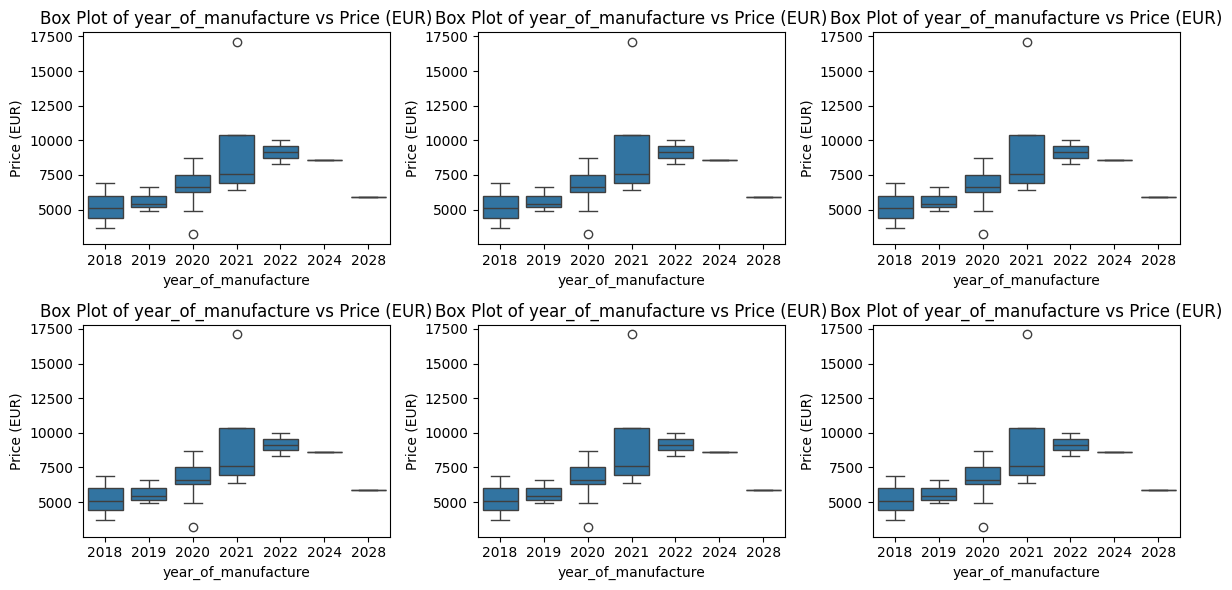

In [25]:
def box_plot(x):
    col=x[0]
    
    fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(12,6))

    for i, ax in enumerate(axes.flatten()):
        sns.boxplot(x=data[col], y=data['Sale price'], ax=ax)
        ax.set_title(f'Box Plot of {col} vs Price (EUR)')
        ax.set_xlabel(col)
        ax.set_ylabel('Price (EUR)')

    plt.tight_layout()
    return plt.show()
        
box_plot(numerical_cols)


#### Correlation Variables
Analyse relation between variables.

Domain: -1 to 1

. 1 -> perfect positive correlation
. -1 -> perfect negative correlation
. 0 -> no correlation


| r (Korrelationskoeffizient) | Stärke des Zusammenhangs |
| --------------------------- | ------------------------ |
| 0.00 – 0.19                 | sehr schwach             |
| 0.20 – 0.39                 | schwach                  |
| 0.40 – 0.59                 | mittel                   |
| 0.60 – 0.79                 | stark                    |
| 0.80 – 1.0                  | sehr stark               |


In [26]:
# pearson_corr = data[numerical_cols].corr(method='pearson')
# plt.figure(figsize=(100, 90))
# sns.heatmap(pearson_corr,
#              annot=True,
#              vmax=1,
#              vmin=-1,
#              fmt=".2f", 
#              cmap='coolwarm', 
#              center=0,
#             annot_kws={"size": 23} )
# plt.title('Pearson Correlation Heatmap')
# plt.xticks(fontsize=20)  
# plt.yticks(fontsize=20)
# plt.show()

VIF (Variance Inflation Factor) misst, wie stark die Varianz eines Regressionskoeffizienten durch die Korrelation mit anderen unabhängigen Variablen „aufgeblasen“ wird.

Einfach gesagt: VIF sagt dir, wie stark ein Feature redundant mit anderen Features ist.

Hohe VIF-Werte → Multikollinearität → Modell instabil

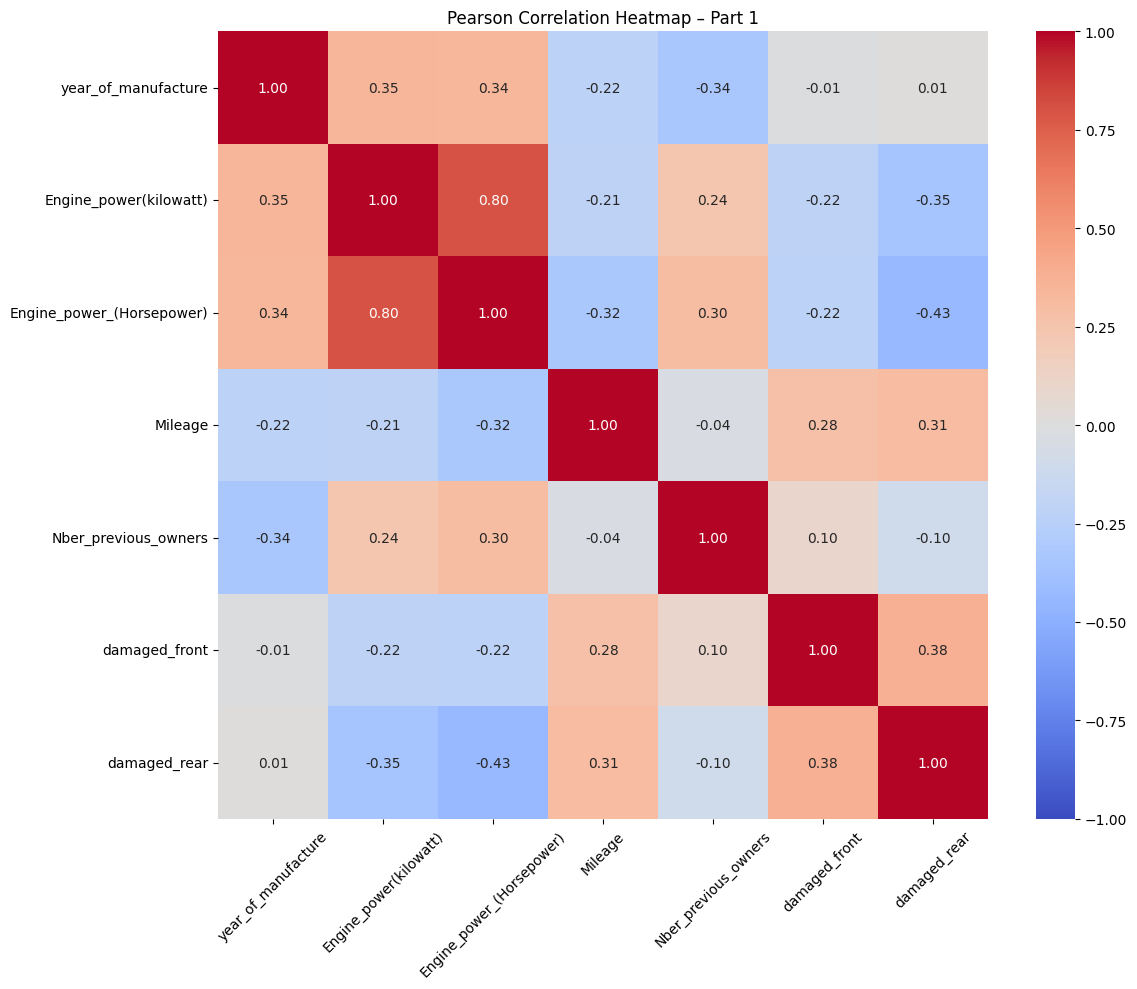

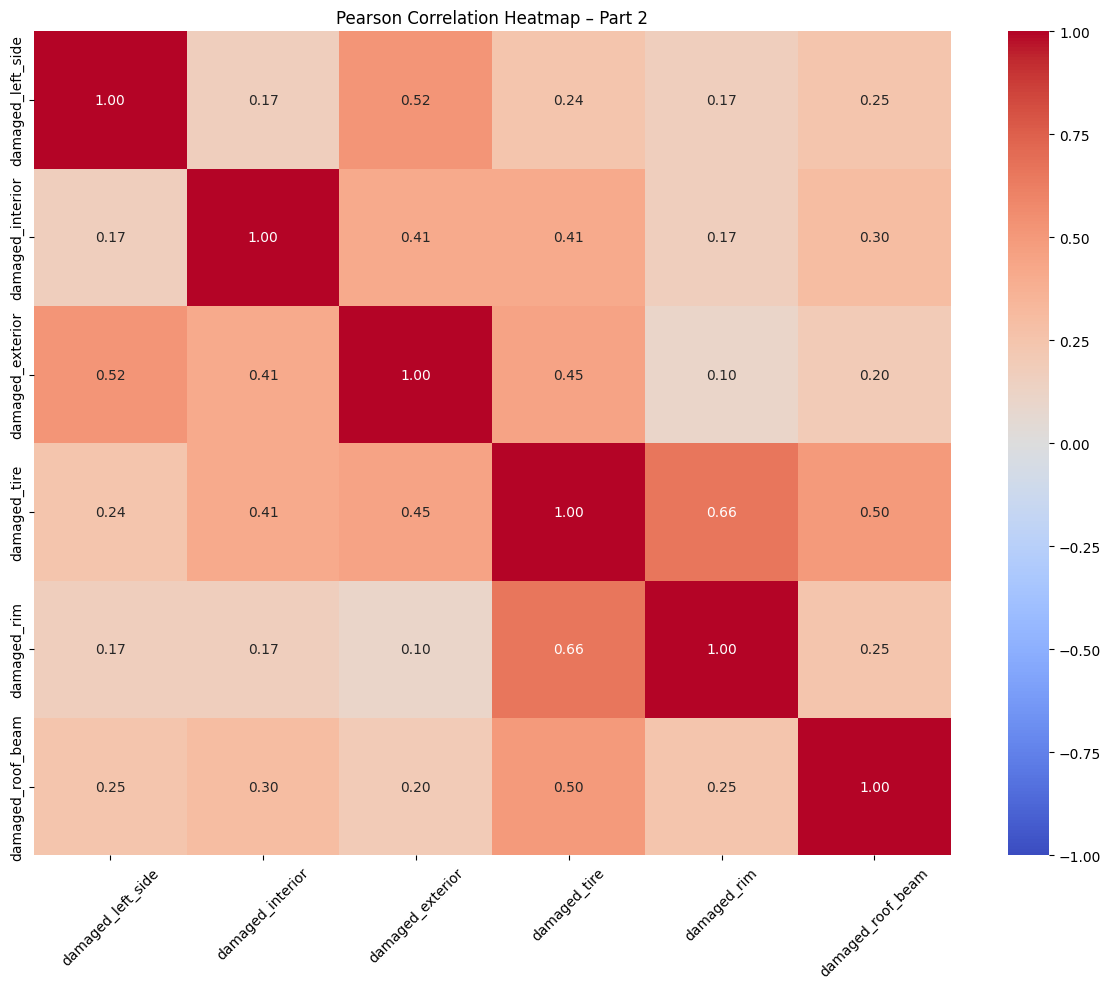

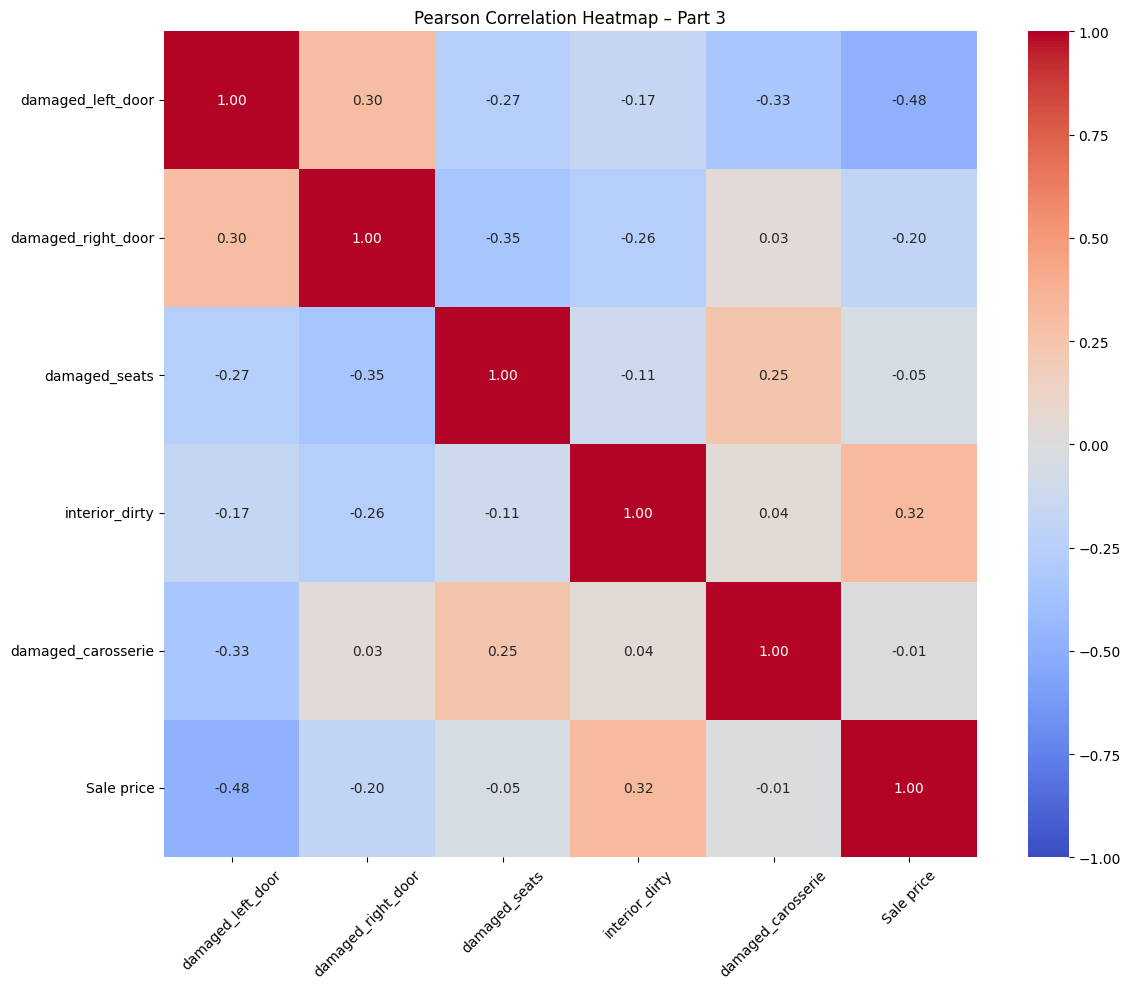

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = data[numerical_cols].corr(method='pearson')

# Anzahl Teile
n_parts = 3

# Spalten in 3 Gruppen splitten
chunks = np.array_split(numerical_cols, n_parts)

for i, cols in enumerate(chunks, 1):

    sub_corr = corr.loc[cols, cols]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        sub_corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        annot_kws={"size": 10}
    )

    plt.title(f"Pearson Correlation Heatmap – Part {i}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [28]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def multi_collinearity_analysis(data):

    # Annahme: numerische Features (ohne Zielvariable)
    numerical_cols = data.select_dtypes(include='number').columns.tolist()
    target = 'Sale price'
    X = data[numerical_cols].drop(target, axis=1).fillna(0)  # unabhängige Variablen

    # 1️. Stark korrelierte Paare erkennen (r > 0.7)
    corr_matrix = X.corr().abs()
    high_corr_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i,j] > 0.7:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j]))

    print("Stark korrelierte Feature-Paare (r > 0.7):")
    for pair in high_corr_pairs:
        print(f"{pair[0]} ↔ {pair[1]} = {pair[2]:.2f}")

    # 2️⃣ VIF berechnen
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print("\nVariance Inflation Factor (VIF) für jedes Feature:")
    print(vif_data)


In [29]:
multi_collinearity_analysis(data)

Stark korrelierte Feature-Paare (r > 0.7):
Engine_power(kilowatt) ↔ Engine_power_(Horsepower) = 0.80

Variance Inflation Factor (VIF) für jedes Feature:
                      Feature         VIF
0         year_of_manufacture  150.200297
1      Engine_power(kilowatt)   41.834249
2   Engine_power_(Horsepower)  161.746706
3                     Mileage   10.541437
4        Nber_previous_owners   24.132544
5               damaged_front    3.573139
6                damaged_rear    4.502147
7           damaged_left_side    4.962569
8            damaged_interior    3.234441
9            damaged_exterior    9.097426
10               damaged_tire   10.744415
11                damaged_rim    6.030914
12          damaged_roof_beam    4.163818
13          damaged_left_door    3.195979
14         damaged_right_door    3.579272
15              damaged_seats    3.611398
16             interior_dirty    5.714233
17         damaged_carosserie    2.948964


In [30]:
print(data.columns.tolist())


['Brand ', 'Model', 'year_of_manufacture', 'Engine_power(kilowatt)', 'Engine_power_(Horsepower)', 'Transmission_type', 'Mileage', 'Fueltype', 'nextTUV', 'Nber_previous_owners', 'Body_style', 'Tire_type', 'Accident_history', 'damaged_front', 'damaged_rear', 'damaged_left_side', 'damaged_interior', 'damaged_exterior', 'damaged_tire', 'damaged_rim', 'damaged_roof_beam', 'damaged_left_door', 'damaged_right_door', 'damaged_seats', 'interior_dirty', 'damaged_carosserie', 'images', 'Sale price']


In [31]:
# Liste der zu löschenden Spalten
cols_to_drop = ['Engine power (Horsepower)', 'Tank capacity', 'has_foldable_seat_tables','damaged_right_side','CO2 (g/km)','Cubic capacity']

# Nur Spalten löschen, die tatsächlich im DataFrame existieren
cols_to_drop_existing = [col for col in cols_to_drop if col in data.columns]

# Löschen
data = data.drop(columns=cols_to_drop_existing)

# Nur numerische Spalten, die aktuell im DataFrame existieren
numerical_cols = [col for col in numerical_cols if col in data.columns]


In [32]:
multi_collinearity_analysis(data)

Stark korrelierte Feature-Paare (r > 0.7):
Engine_power(kilowatt) ↔ Engine_power_(Horsepower) = 0.80

Variance Inflation Factor (VIF) für jedes Feature:
                      Feature         VIF
0         year_of_manufacture  150.200297
1      Engine_power(kilowatt)   41.834249
2   Engine_power_(Horsepower)  161.746706
3                     Mileage   10.541437
4        Nber_previous_owners   24.132544
5               damaged_front    3.573139
6                damaged_rear    4.502147
7           damaged_left_side    4.962569
8            damaged_interior    3.234441
9            damaged_exterior    9.097426
10               damaged_tire   10.744415
11                damaged_rim    6.030914
12          damaged_roof_beam    4.163818
13          damaged_left_door    3.195979
14         damaged_right_door    3.579272
15              damaged_seats    3.611398
16             interior_dirty    5.714233
17         damaged_carosserie    2.948964


In [33]:
print(data.columns.tolist())



['Brand ', 'Model', 'year_of_manufacture', 'Engine_power(kilowatt)', 'Engine_power_(Horsepower)', 'Transmission_type', 'Mileage', 'Fueltype', 'nextTUV', 'Nber_previous_owners', 'Body_style', 'Tire_type', 'Accident_history', 'damaged_front', 'damaged_rear', 'damaged_left_side', 'damaged_interior', 'damaged_exterior', 'damaged_tire', 'damaged_rim', 'damaged_roof_beam', 'damaged_left_door', 'damaged_right_door', 'damaged_seats', 'interior_dirty', 'damaged_carosserie', 'images', 'Sale price']


In [34]:
%store data
%store numerical_cols

Stored 'data' (DataFrame)
Stored 'numerical_cols' (list)
